In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [45]:
path = "../data/raw/time_series_15min_singleindex.csv"
df = pd.read_csv(path, parse_dates=["utc_timestamp"])
df = df.set_index("utc_timestamp")

In [46]:
df.describe()

,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,...,HU_solar_generation_actual,HU_wind_onshore_generation_actual,LU_load_actual_entsoe_transparency,LU_load_forecast_entsoe_transparency,NL_load_actual_entsoe_transparency,NL_load_forecast_entsoe_transparency,NL_solar_generation_actual,NL_wind_generation_actual,NL_wind_offshore_generation_actual,NL_wind_onshore_generation_actual
count,201598.000000,201598.000000,131378.000000,201352.000000,201406.000000,201598.000000,201502.000000,201598.000000,201502.000000,175199.000000,...,35859.000000,193021.000000,198794.000000,197182.000000,201598.000000,201598.000000,181382.000000,193733.000000,193733.000000,200901.000000
mean,7070.161704,7039.857678,33.947254,135.283656,729.651345,9808.396916,9759.333258,55492.589700,54791.506975,42378.044395,...,177.082384,77.224803,470.611662,489.717953,12578.456013,12809.253119,162.335138,986.695963,340.447829,656.203710
std,1403.676483,1357.674902,16.815854,199.645788,693.810792,1398.512250,1384.276280,10041.148871,9523.623592,4306.349752,...,268.936739,76.613078,97.290734,114.502520,2290.400411,2507.304378,334.727140,831.882376,283.602966,635.109461
min,615.200000,3731.650000,-149.990000,0.000000,0.000000,6129.490000,6500.050000,29158.120000,28675.410000,37248.000000,...,0.000000,0.000000,10.000000,9.000000,6474.000000,4333.890000,0.000000,0.000000,0.000000,0.000000
25%,5938.800000,5940.000000,23.960000,0.000000,160.315000,8703.340000,8666.115000,47099.780000,46962.280000,38810.000000,...,0.000000,14.510000,405.000000,415.000000,10779.000000,10948.245000,0.000000,301.760000,88.270000,168.370000
50%,7032.400000,7019.120000,33.000000,16.000000,492.000000,9809.285000,9755.595000,55117.400000,54749.695000,40941.000000,...,2.820000,50.860000,469.000000,478.000000,12447.045000,12560.645000,0.000000,751.250000,271.920000,439.200000
75%,8080.800000,7987.442500,43.010000,224.000000,1140.000000,10856.987500,10815.052500,64337.655000,62901.085000,46092.000000,...,297.605000,120.620000,545.000000,549.000000,14301.000000,14638.560000,146.000000,1516.560000,579.220000,975.730000
max,10836.000000,11667.590000,977.740000,1172.000000,2992.000000,13815.370000,13653.090000,77852.940000,76392.520000,50508.000000,...,1018.140000,435.320000,861.100000,1356.000000,19404.440000,28269.770000,2296.000000,4322.460000,935.830000,3781.950000


In [47]:
cols_to_kepp = [
  "HU_solar_generation_actual",
  "DE_LU_load_forecast_entsoe_transparency",
  "DE_LU_load_actual_entsoe_transparency",
  "DE_LU_solar_generation_actual",
  "DE_LU_wind_generation_actual",
  "DE_LU_wind_onshore_generation_actual",
  "DE_LU_wind_offshore_generation_actual",
  "AT_price_day_ahead",
  "DE_solar_profile",
  "DE_wind_profile",
  "DE_solar_capacity",
  "DE_wind_capacity",
  'DE_solar_generation_actual',
  'DE_wind_generation_actual',
  'DE_load_actual_entsoe_transparency'
]

df = df[cols_to_kepp]

In [ ]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["is_night"] = df["hour"].between(0, 6).astype(int)

target = 'DE_load_actual_entsoe_transparency'

In [50]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(10)

HU_solar_generation_actual                 165745
DE_LU_load_forecast_entsoe_transparency    134982
DE_LU_load_actual_entsoe_transparency      131509
DE_LU_solar_generation_actual              131451
DE_LU_wind_generation_actual               131422
DE_LU_wind_onshore_generation_actual       131422
DE_LU_wind_offshore_generation_actual      131422
AT_price_day_ahead                          70226
DE_solar_profile                            26821
DE_wind_profile                             26707
dtype: int64

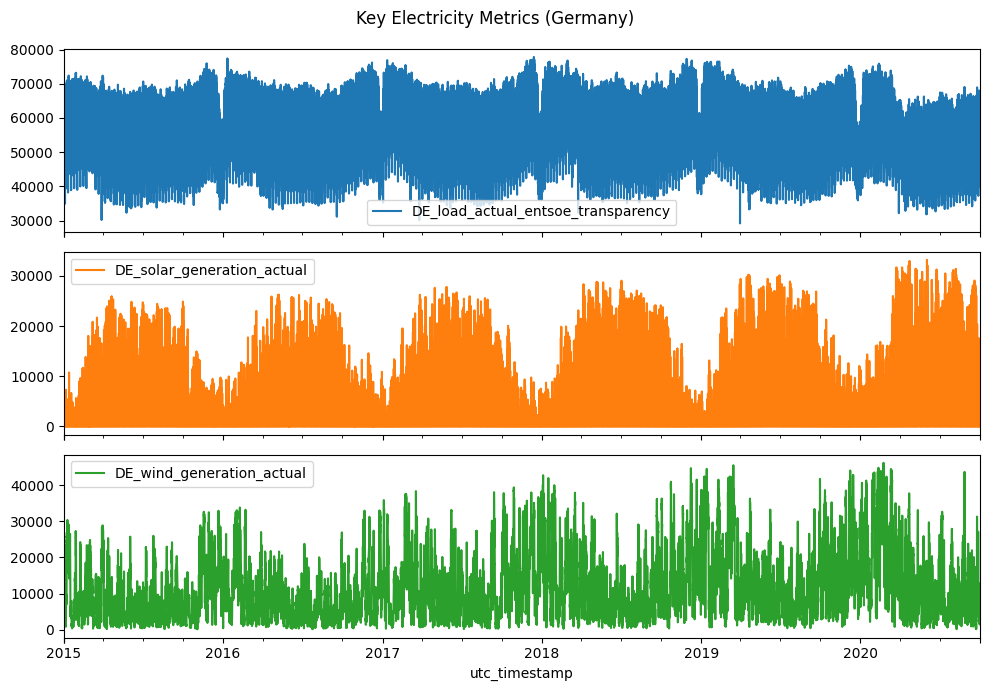

In [51]:
import matplotlib.pyplot as plt

columns_to_plot = [
    'DE_load_actual_entsoe_transparency',
    'DE_solar_generation_actual',
    'DE_wind_generation_actual'
]

df[columns_to_plot].plot(subplots=True, figsize=(10, 7), title="Key Electricity Metrics (Germany)")
plt.tight_layout()
plt.show()


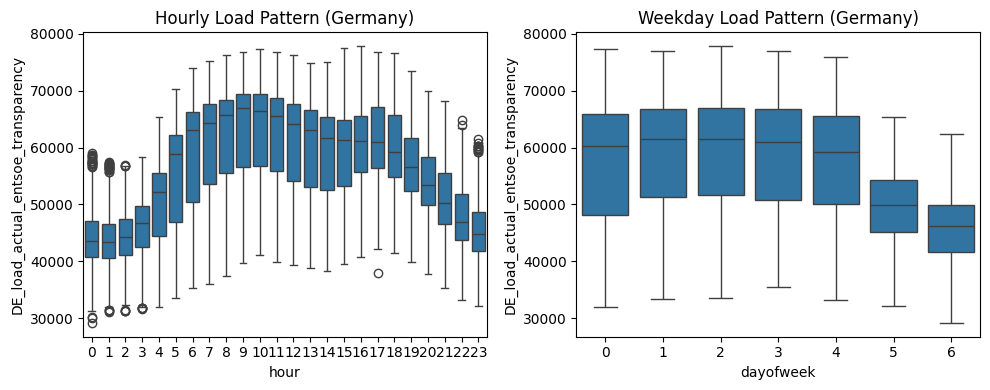

In [59]:
# Create side-by-side plots with custom size
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # width=14, height=6 (in inches)

# Boxplot 1: Hourly Load Pattern
sns.boxplot(x="hour", y="DE_load_actual_entsoe_transparency", data=df, ax=axes[0])
axes[0].set_title("Hourly Load Pattern (Germany)")

# Boxplot 2: Weekday Load Pattern
sns.boxplot(x="dayofweek", y="DE_load_actual_entsoe_transparency", data=df, ax=axes[1])
axes[1].set_title("Weekday Load Pattern (Germany)")

# Adjust layout
plt.tight_layout()
plt.show()

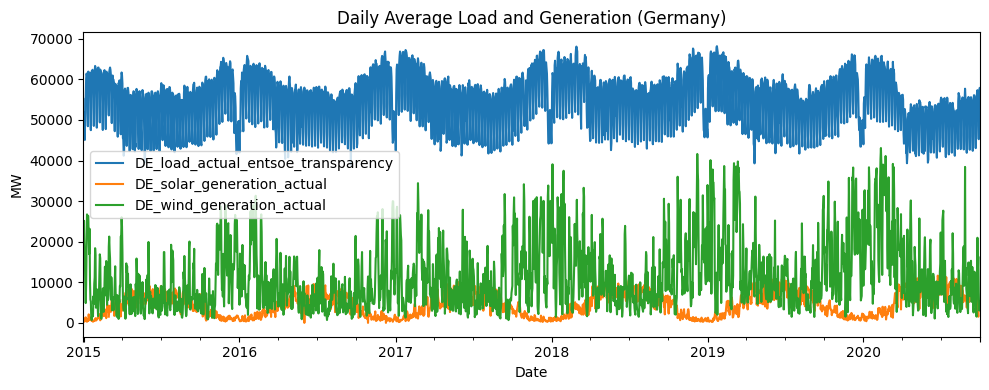

In [54]:
# Option 1: Resample only numeric columns
df_numeric = df.select_dtypes(include='number')
df_daily = df_numeric.resample("D").mean()


df_daily[[
    "DE_load_actual_entsoe_transparency",
    "DE_solar_generation_actual",
    "DE_wind_generation_actual"
]].plot(figsize=(10, 4))

plt.title("Daily Average Load and Generation (Germany)")
plt.ylabel("MW")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

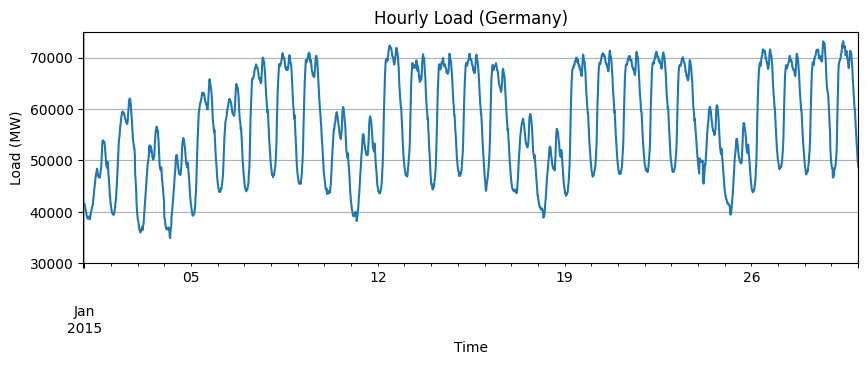

In [78]:
ax = df['DE_load_actual_entsoe_transparency'].plot(figsize=(10, 3), title="Hourly Load (Germany)")

# Set limits (example values, adjust as needed)
plt.xlim(['2014-12-31 23:00:00+0000', '2015-01-30 00:00:00+0000'])  # X-axis: full datetime range
plt.ylim(30000, 75000)                      # Y-axis: specific load range

plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.grid(True)
plt.show()

In [80]:
# Step 1: Calculate missing value percentages
missing_percentage = (df.isna().sum() / len(df)) * 100

# Step 2: Identify columns with > 65% missing data
cols_to_drop = missing_percentage[missing_percentage > 65].index

# Step 3: Drop those columns from the DataFrame
df = df.drop(columns=cols_to_drop)

In [82]:
missing_percentage

AT_price_day_ahead                    34.833634
DE_solar_profile                      13.303803
DE_wind_profile                       13.247257
DE_solar_capacity                     13.097458
DE_wind_capacity                      13.097458
DE_solar_generation_actual             0.208329
DE_wind_generation_actual              0.150791
DE_load_actual_entsoe_transparency     0.002976
hour                                   0.000000
dayofweek                              0.000000
month                                  0.000000
is_weekend                             0.000000
is_night                               0.000000
dtype: float64

In [83]:
cols_int = [
    "AT_price_day_ahead",
    "DE_solar_profile",
    "DE_wind_profile",
    "DE_solar_capacity",
    "DE_wind_capacity"
]

df[cols_int] = df[cols_int].interpolate().fillna(method='ffill').fillna(method='bfill')

C:\Users\usuario\AppData\Local\Temp\ipykernel_22228\817185974.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[cols_int] = df[cols_int].interpolate().fillna(method='ffill').fillna(method='bfill')


In [ ]:
df['lag_15min'] = df[target].shift(1)
df['lag_1hour'] = df[target].shift(4)
df['lag_1day'] = df[target].shift(96)
df['lag_1week'] = df[target].shift(96 * 7)

df['rolling_1hour'] = df[target].rolling(window=4).mean()       # 1 hour
df['rolling_6hour'] = df[target].rolling(window=24).mean()      # 6 hours
df['rolling_1day'] = df[target].rolling(window=96).mean()       # 1 day
df['rolling_1week'] = df[target].rolling(window=96*7).mean()    # 1 week

df['rolling_1hour'] = df[target].rolling(window=4).std()       # 1 hour
df['rolling_6hour'] = df[target].rolling(window=24).std()      # 6 hours
df['rolling_1day'] = df[target].rolling(window=96).std()       # 1 day
df['rolling_1week'] = df[target].rolling(window=96*7).std()    # 1 week

In [90]:
df.columns

Index(['AT_price_day_ahead', 'DE_solar_profile', 'DE_wind_profile',
       'DE_solar_capacity', 'DE_wind_capacity', 'DE_solar_generation_actual',
       'DE_wind_generation_actual', 'DE_load_actual_entsoe_transparency',
       'hour', 'dayofweek', 'month', 'is_weekend', 'is_night', 'lag_15min',
       'lag_1hour', 'lag_1day', 'lag_1week', 'rolling_1hour', 'rolling_6hour',
       'rolling_1day', 'rolling_1week'],
      dtype='object')

In [103]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna

# Clean dataset
df_clean = df.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=['DE_load_actual_entsoe_transparency'])  # Ensure target is clean

target = 'DE_load_actual_entsoe_transparency'
features = [col for col in df_clean.columns if col != target]

X = df_clean[features]
y = df_clean[target]

# Time-based split (do not shuffle)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define objective function for Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'objective': 'reg:squarederror'
    }

    model = xgb.XGBRegressor(**params)
    model.set_params(eval_metric='rmse')  # ✅ Fix for version compatibility

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    preds = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    return rmse

# Run Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)

# Train final model with best params
best_params = study.best_trial.params
best_params['random_state'] = 42
best_params['objective'] = 'reg:squarederror'

model = xgb.XGBRegressor(**best_params)
model.fit(X_train, y_train)

# Final evaluation
y_pred = model.predict(X_valid)
print("\nFinal Model Performance:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_valid, y_pred)):.3f}")
print(f"MAE: {mean_absolute_error(y_valid, y_pred):.3f}")
print(f"R²: {r2_score(y_valid, y_pred):.3f}")

[I 2025-07-04 15:26:26,882] A new study created in memory with name: no-name-079b9980-3db1-47ee-8df2-75e2eef81b98
[I 2025-07-04 15:26:28,060] Trial 0 finished with value: 406.5242266932803 and parameters: {'n_estimators': 90, 'max_depth': 8, 'learning_rate': 0.04157327495743117, 'subsample': 0.7652614068688364, 'colsample_bytree': 0.9088330305733707, 'reg_alpha': 0.4057753471809601, 'reg_lambda': 0.9468350284770916}. Best is trial 0 with value: 406.5242266932803.
[I 2025-07-04 15:26:30,570] Trial 1 finished with value: 414.9555507168789 and parameters: {'n_estimators': 113, 'max_depth': 10, 'learning_rate': 0.042566504501102574, 'subsample': 0.8017444986611306, 'colsample_bytree': 0.6102258014224334, 'reg_alpha': 0.9341075990502844, 'reg_lambda': 0.8227587758863117}. Best is trial 0 with value: 406.5242266932803.
[I 2025-07-04 15:26:31,290] Trial 2 finished with value: 412.57712229560906 and parameters: {'n_estimators': 79, 'max_depth': 6, 'learning_rate': 0.18978529743191183, 'subsamp

✅ Best trial:
FrozenTrial(number=38, state=TrialState.COMPLETE, values=[307.788097277773], datetime_start=datetime.datetime(2025, 7, 4, 15, 29, 15, 621403), datetime_complete=datetime.datetime(2025, 7, 4, 15, 29, 25, 481597), params={'n_estimators': 271, 'max_depth': 10, 'learning_rate': 0.040399376318502975, 'subsample': 0.7239659987274459, 'colsample_bytree': 0.9774070099919425, 'reg_alpha': 0.08289507488202219, 'reg_lambda': 0.00776272842002157}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=300, log=False, low=50, step=1), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=False, low=0.01, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 'reg_alpha': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'reg_lambda': FloatDistribution(high

In [ ]:
📊 Final Model Performance:
RMSE: 307.788
MAE: 222.108
R²: 0.999

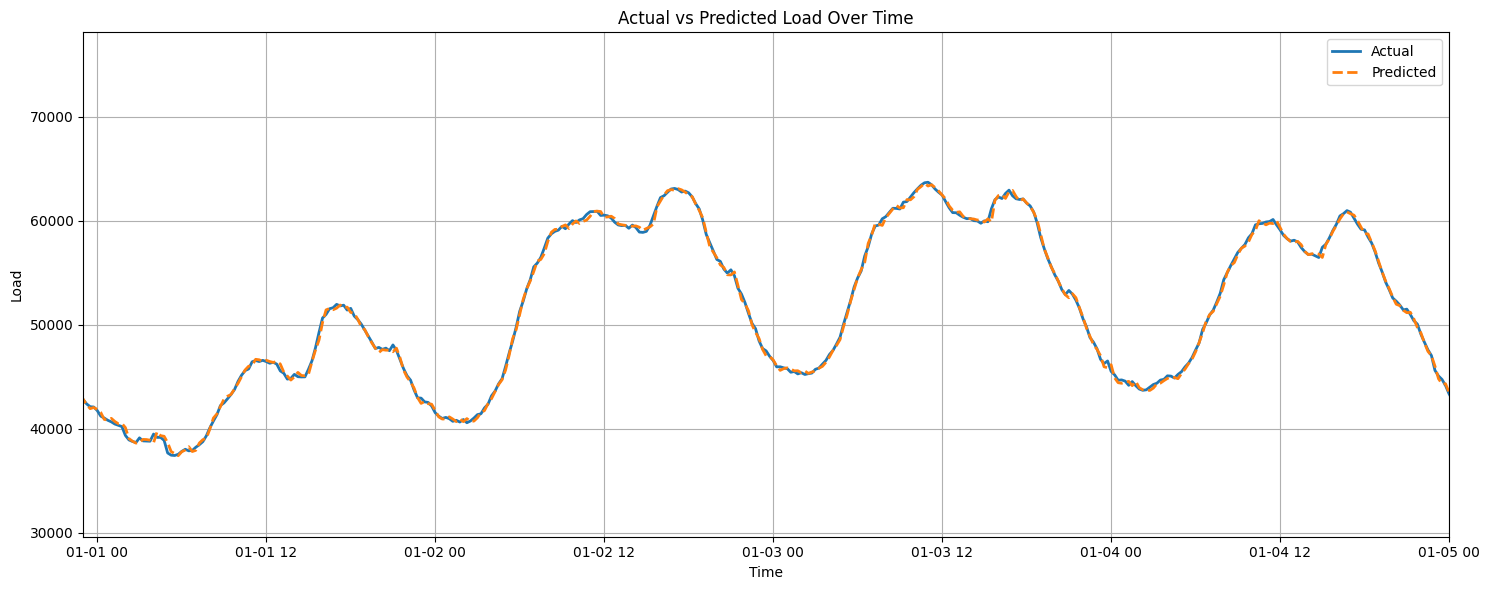

In [113]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure your datetime index is properly parsed
dates = X_valid.index

# Build the DataFrame for plotting
df_plot = pd.DataFrame({
    'Actual': y_valid,
    'Predicted': y_pred
}, index=dates)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(df_plot.index, df_plot['Actual'], label='Actual', linewidth=2)
plt.plot(df_plot.index, df_plot['Predicted'], label='Predicted', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Load Over Time')
plt.xlabel('Time')
plt.ylabel('Load')

# Use pd.to_datetime to ensure the date range matches your index format
plt.xlim(pd.to_datetime('2019-12-31 23:00:00+0000'), pd.to_datetime('2020-01-05 00:00:00+0000'))

#plt.ylim(50000, 75000)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



100%|===================| 161269/161278 [88:37<00:00]        

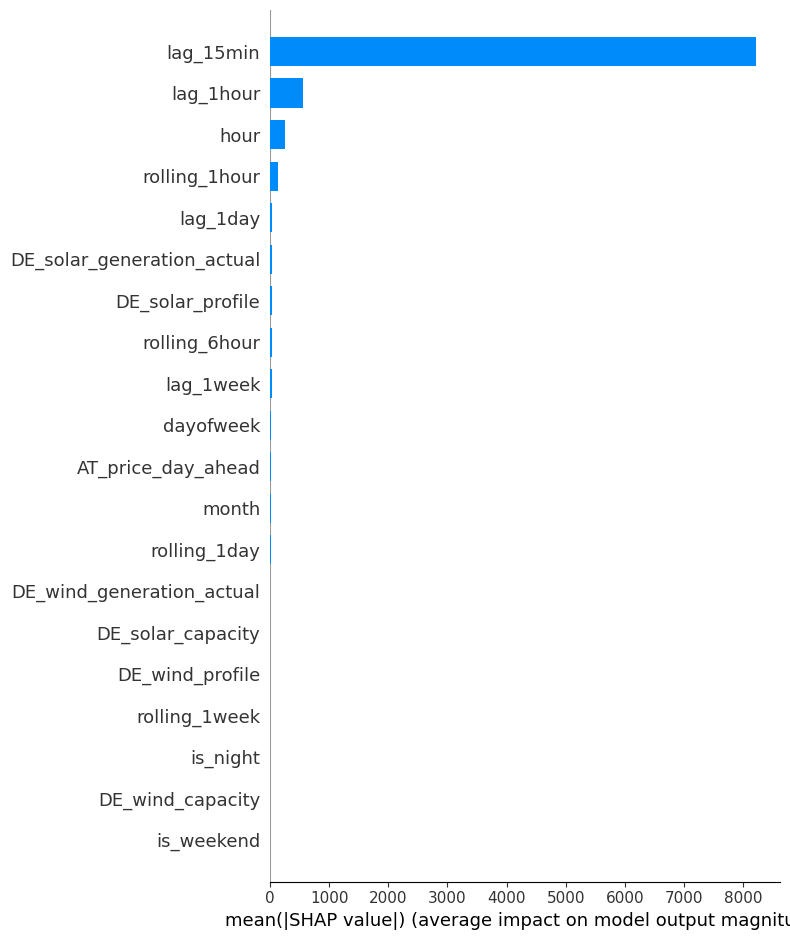

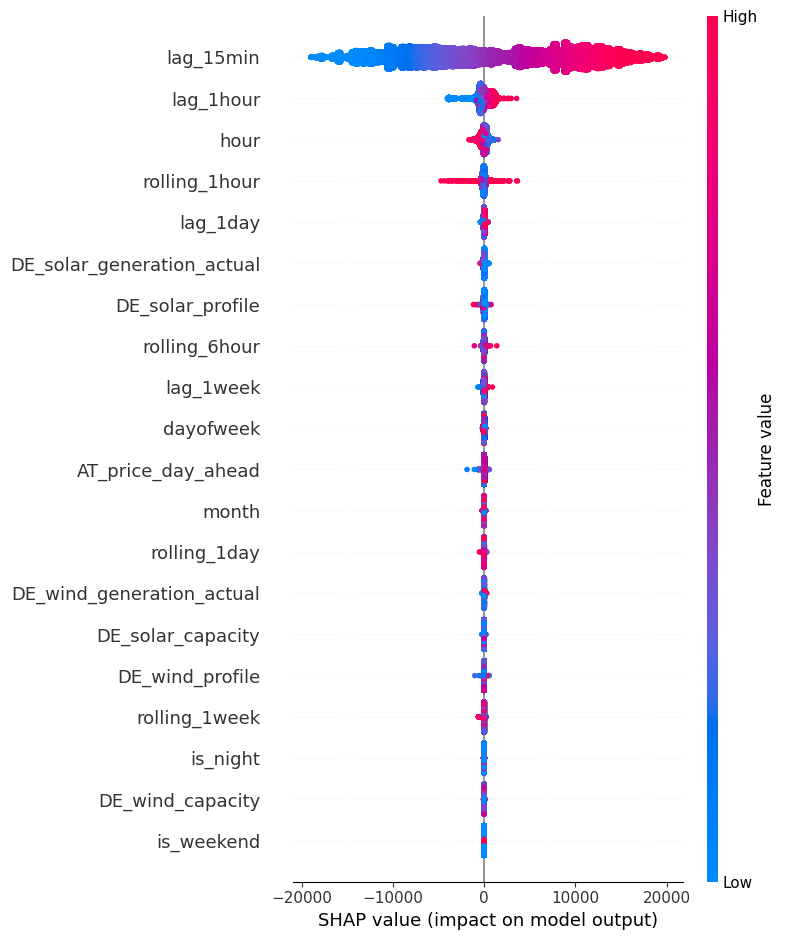

In [114]:
# Initialize SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values
shap_values = explainer(X_train)

# Summary plot (feature importance)
shap.summary_plot(shap_values, X_train, plot_type='bar')

# Optional: Detailed summary plot showing distribution per feature
shap.summary_plot(shap_values, X_train)

### PCA to infer most important features

In [94]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Select your features and standardize them
features = [col for col in df.columns if col not in ['datetime', target]]
X = df[features].dropna()
X_scaled = StandardScaler().fit_transform(X)

# 2. Fit PCA
pca = PCA()
pca.fit(X_scaled)

# 3. Create a DataFrame of loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(features))],
                        index=features)

# 4. Show top contributors to PC1
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False)
print("Top features contributing to PC1:")
print(top_pc1.head(15))


Top features contributing to PC1:
lag_1hour                     0.427527
lag_15min                     0.424988
lag_1week                     0.407148
lag_1day                      0.337426
is_night                      0.256415
is_weekend                    0.239702
rolling_1day                  0.225820
DE_solar_profile              0.203776
dayofweek                     0.195960
AT_price_day_ahead            0.192941
DE_solar_generation_actual    0.191874
hour                          0.127394
rolling_1week                 0.066274
DE_solar_capacity             0.053023
DE_wind_profile               0.041347
Name: PC1, dtype: float64
